# Fraud Detection: Sampling, Feature Analysis, Imbalance Handling & Classification
**Assignment 1 – Data Analytics** &nbsp;|&nbsp; **Dataset:** `Fraud Detection Dataset.csv`

## Objective
The data contains 51,000 payment transactions, each labelled as fraudulent (`1`) or genuine (`0`).
This notebook walks through the full analytics workflow, in this order:

1. **Sampling**
2. **Pre-processing**
3. **Feature analysis**
4. **Imbalance handling**
5. **Modelling**
6. **Evaluation**



> **Reproducibility:** every random operation uses the same seed (`SEED = 42`), so re-running the notebook gives identical results.

## 1. Setup



In [2]:
import pandas as pd
from pathlib import Path

# Define potential dataset file paths
DATA_CANDIDATES = ["Fraud Detection Dataset.csv", "Fraud_Detection_Dataset.csv"]
DATA_FILE = next((f for f in DATA_CANDIDATES if Path(f).exists()), DATA_CANDIDATES[0])

# Load the dataset
df = pd.read_csv(DATA_FILE)

# Inspect dataset dimensions and column names
print("Dataset Shape:", df.shape)
print("Columns in Dataset:", list(df.columns))

# Display the first few rows
df.head()

Dataset Shape: (51000, 12)
Columns in Dataset: ['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


**What we see:** the dataset has **51,000 rows and 12 columns** – the 11 descriptive columns from the data dictionary plus the `Fraudulent` target.

In [3]:
import warnings
from collections import Counter
from pathlib import Path

# Data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: preprocessing, feature selection, models and metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# imbalanced-learn: oversampling techniques
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Global settings used throughout the notebook
SEED = 42
DATA_CANDIDATES = ["Fraud Detection Dataset.csv", "Fraud_Detection_Dataset.csv"]
DATA_FILE = next((f for f in DATA_CANDIDATES if Path(f).exists()), DATA_CANDIDATES[0])

print("All libraries imported successfully.")

All libraries imported successfully.


### 2. Sampling Techniques
Sampling means working with a subset of the data. Different strategies suit different goals, so we try several.
A small helper is defined first because stratified, proportional and equal sampling all do the same thing:
*split by `Location`, draw rows from each group, then stack the pieces*.

In [ ]:
# Rows without a Location cannot be assigned to any group, so group-based sampling uses only the valid rows
df_with_location = df.dropna(subset=["Location"]).copy()


def sample_per_location(data, draw):
    """Apply `draw(group)` to every Location group and combine the results into one DataFrame."""
    pieces = [draw(group) for _, group in data.groupby("Location")]
    return pd.concat(pieces, ignore_index=True)

### 2.1 Partition Sampling (70%)
Takes a random 70% of all rows – the usual way to carve out a working or training portion of a dataset.

In [ ]:
PARTITION_FRACTION = 0.70
partition = df.sample(frac=PARTITION_FRACTION, random_state=SEED)
print("Partition Length:", len(partition))
partition.head()

Partition Length: 35700


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


**Output:** 70% of 51,000 = **35,700 rows**.

### 2.2 Simple Random Sampling (100 rows)
Every row has an equal chance of selection. It is unbiased, but small categories can be missed by chance.

In [ ]:
sample_random = df.sample(n=100, random_state=SEED)
print("Random Sample Shape:", sample_random.shape)
sample_random.head()

Random Sample Shape: (100, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


**Output:** a sample of **100 rows × 12 columns**.

### 2.3 Stratified Sampling (10% from each Location)
The data is split into strata (one per city) and 10% is drawn from each, so every city stays represented
in proportion to its size.

In [ ]:
sample_stratified = sample_per_location(
    df_with_location,
    draw=lambda grp: grp.sample(frac=0.1, random_state=SEED),
)
print("Stratified Sample Shape (10% per Location):", sample_stratified.shape)
sample_stratified.head()

Stratified Sample Shape (10% per Location): (4844, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
1,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
2,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
3,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
4,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


**Output:** **4,844 rows** (10% of each of the 8 cities, rounded). Rows with a missing `Location` are excluded.

### Task 1 – Fixed Sample Size (500 rows)
The total must be exactly **500**. Each city receives a share proportional to its size in the data
(*proportional allocation*): `city_share = 500 × city_rows / total_rows`.

In [ ]:
TARGET_SIZE = 500
valid_total = len(df_with_location)

stratified_500 = sample_per_location(
    df_with_location,
    draw=lambda grp: grp.sample(n=int(round(TARGET_SIZE * len(grp) / valid_total)), random_state=SEED),
)
print("Total Stratified Sample Count:", len(stratified_500))
stratified_500.head()

Total Stratified Sample Count: 500


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
1,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
2,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
3,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
4,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


**Output:** exactly **500 rows**. Rounding gives 63 rows to the four largest cities and 62 to the other four (4×63 + 4×62 = 500).

### Task 2 – Location-wise Count
We compare how the cities are distributed in (a) the full dataset and (b) our 500-row stratified sample.
If the stratified sample is representative, the two should look alike.

--- Full Dataset Location-wise Count ---
Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
NaN              2547
Name: count, dtype: int64

--- Stratified Sample (500) Location-wise Count ---
Location
Boston           63
Chicago          63
New York         63
Seattle          63
Houston          62
Los Angeles      62
Miami            62
San Francisco    62
Name: count, dtype: int64


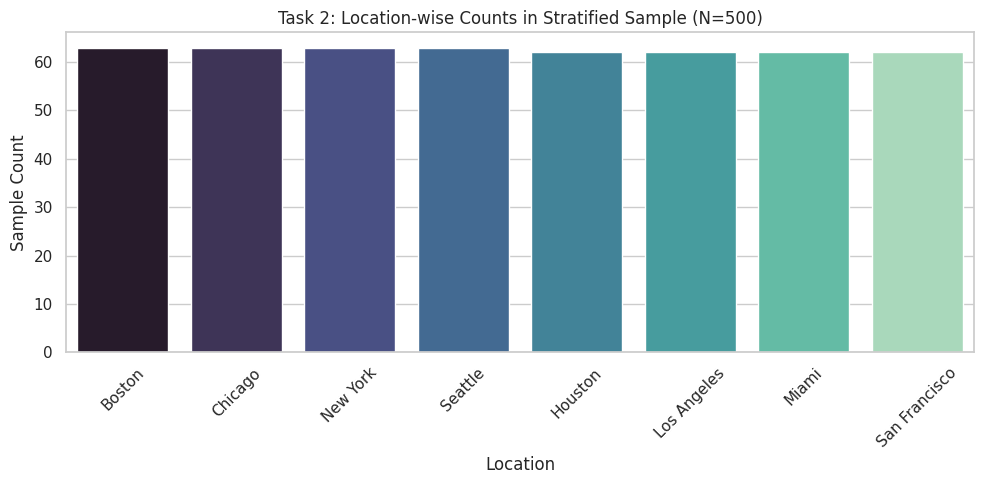

In [ ]:
print("--- Full Dataset Location-wise Count ---")
print(df["Location"].value_counts(dropna=False))

print("\n--- Stratified Sample (500) Location-wise Count ---")
loc_counts_500 = stratified_500["Location"].value_counts()
print(loc_counts_500)

plt.figure(figsize=(10, 5))
sns.barplot(x=loc_counts_500.index, y=loc_counts_500.values, palette="mako")
plt.title("Task 2: Location-wise Counts in Stratified Sample (N=500)")
plt.xlabel("Location")
plt.ylabel("Sample Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Output:** the eight cities each have roughly 6,000 transactions (Boston is largest with 6,149), and
2,547 rows have no location (`NaN`). The 500-row sample mirrors this almost perfectly, which is why the bars are nearly equal.

### Task 3 – Equal Count per Location
Instead of proportional shares, we force **every city to contribute the same number of rows (50)**.
This removes any size advantage between cities.

In [ ]:
ROWS_PER_LOCATION = 50

sample_equalized = sample_per_location(
    df_with_location,
    draw=lambda grp: grp.sample(n=min(ROWS_PER_LOCATION, len(grp)), random_state=SEED),
)
print("Equalized Location Counts:")
print(sample_equalized["Location"].value_counts())
print("Total Equalized Sample Size:", len(sample_equalized))

Equalized Location Counts:
Location
Boston           50
Chicago          50
Houston          50
Los Angeles      50
Miami            50
New York         50
San Francisco    50
Seattle          50
Name: count, dtype: int64
Total Equalized Sample Size: 400


**Output:** 50 rows × 8 cities = **400 rows**. (`min(...)` protects against a city having fewer than 50 rows.)

### 2.4 Cluster Sampling
Here a *whole group* is the unit of selection. We randomly pick 2 cities and keep **all** of their transactions –
useful when data is collected city by city.

In [ ]:
all_locations = df_with_location["Location"].unique()
chosen_clusters = pd.Series(all_locations).sample(n=2, random_state=SEED)
print("Selected Clusters (Locations):", chosen_clusters.tolist())

sample_cluster = df[df["Location"].isin(chosen_clusters)]
print("Cluster Sample Size:", len(sample_cluster))
sample_cluster.head(10)

Selected Clusters (Locations): ['New York', 'Miami']
Cluster Sample Size: 12101


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0
22,T23,1769,2222.86,POS Payment,14.0,Mobile,Miami,1,103,10,UPI,0
25,T26,4485,NaN,Online Purchase,17.0,Mobile,Miami,2,63,8,UPI,0
26,T27,3853,4065.44,Online Purchase,21.0,Tablet,New York,4,99,9,Net Banking,0
30,T31,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
32,T33,1459,2212.25,Online Purchase,10.0,Desktop,New York,4,14,13,UPI,0


**Output:** the random draw selected **New York** and **Miami**, giving 6,110 + 5,991 = **12,101 rows**.

### Task 4 – Sampling from the 5 Most and 5 Least Listed Locations
We rank the cities by number of transactions, take the top 5 and bottom 5, and draw 300 random rows from each group.

In [ ]:
location_counts = df["Location"].value_counts()
most_listed = location_counts.head(5).index.tolist()
least_listed = location_counts.tail(5).index.tolist()

print("Top 5 Most Listed Locations:", most_listed)
print("Bottom 5 Least Listed Locations:", least_listed)


def draw_from_locations(locations, n=300):
    """Random sample of n rows taken from the rows belonging to the given locations."""
    return df[df["Location"].isin(locations)].sample(n=n, random_state=SEED)


sample_top5 = draw_from_locations(most_listed)
sample_bottom5 = draw_from_locations(least_listed)

print("\nSampled Top 5 Locations Count:")
print(sample_top5["Location"].value_counts())

print("\nSampled Bottom 5 Locations Count:")
print(sample_bottom5["Location"].value_counts())

Top 5 Most Listed Locations: ['Boston', 'New York', 'Seattle', 'Chicago', 'Houston']
Bottom 5 Least Listed Locations: ['Chicago', 'Houston', 'Los Angeles', 'Miami', 'San Francisco']

Sampled Top 5 Locations Count:
Location
Seattle     74
Boston      64
Chicago     59
Houston     56
New York    47
Name: count, dtype: int64

Sampled Bottom 5 Locations Count:
Location
Chicago          70
San Francisco    67
Los Angeles      58
Miami            56
Houston          49
Name: count, dtype: int64


**Output & remark:** the top-5 group is Boston, New York, Seattle, Chicago, Houston, and the bottom-5 group is
Chicago, Houston, Los Angeles, Miami, San Francisco. **Chicago and Houston appear in both lists** because the data has
only 8 cities, so any "top 5" and "bottom 5" must overlap. Missing locations (`NaN`) are not counted in the ranking.
The 300 rows are drawn at random from the whole group, so the per-city counts differ slightly rather than being equal.

4.Missing Values

In [ ]:
print("--- Missing Values Count ---")
print(df.isnull().sum())

df_clean = df.copy()

# Numeric columns -> median
for column in ["Transaction_Amount", "Time_of_Transaction"]:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Categorical columns -> "Unknown"
for column in ["Device_Used", "Location", "Payment_Method"]:
    df_clean[column] = df_clean[column].fillna("Unknown")

# Remove exact duplicates
duplicate_count = df_clean.duplicated().sum()
print(f"\nExact Duplicate Rows Count: {duplicate_count}")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Dataset Shape after Cleaning:", df_clean.shape)

--- Missing Values Count ---
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

Exact Duplicate Rows Count: 881
Dataset Shape after Cleaning: (50119, 12)


**Output:** about 2,500 values were missing in each of five columns (amount, time, device, location, payment method).
After imputation, **881 duplicate rows** were removed, leaving **50,119 rows**.

### 3.1 Correlation Analysis
Pearson correlation measures the *linear* relationship between each numeric column and the target `Fraudulent`
(values range from −1 to +1; near 0 means no linear relationship).

Correlation with Fraudulent:
Fraudulent                          1.000000
User_ID                             0.007220
Time_of_Transaction                 0.005750
Transaction_Amount                  0.005633
Account_Age                         0.005517
Previous_Fraudulent_Transactions    0.000766
Number_of_Transactions_Last_24H    -0.003964
Name: Fraudulent, dtype: float64


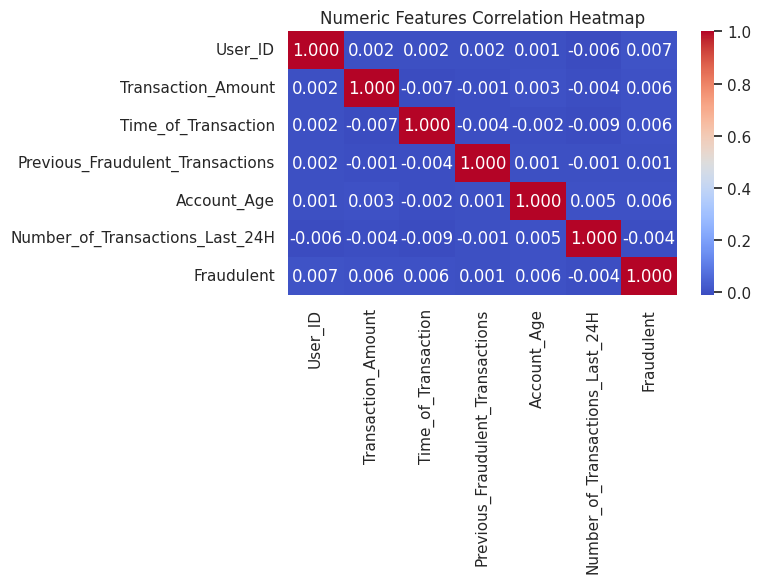

In [ ]:
numeric_data = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr(numeric_only=True)

print("Correlation with Fraudulent:")
print(corr_matrix["Fraudulent"].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Numeric Features Correlation Heatmap")
plt.tight_layout()
plt.show()

**Interpretation:** every correlation with `Fraudulent` is below **0.01** in absolute value (strongest: `User_ID` at 0.007).
No numeric feature has a meaningful linear relationship with fraud.

### 3.2 Chi-Square Test
The chi-square test checks whether a feature and the target are statistically **dependent**. A small p-value (< 0.05)
suggests dependence. Preparation steps:

1. **Label-encode** the text columns into integers.
2. **Min-max scale** all features to [0, 1] – chi-square requires non-negative inputs.

Chi-Square Test Feature Scores:
                         Feature  Chi2_Score  P_Value
                        Location    0.698092 0.403425
                Transaction_Type    0.533269 0.465236
             Time_of_Transaction    0.284829 0.593553
              Transaction_Amount    0.260825 0.609554
                     Account_Age    0.259055 0.610770
                     Device_Used    0.172912 0.677537
 Number_of_Transactions_Last_24H    0.150660 0.697906
Previous_Fraudulent_Transactions    0.007385 0.931516
                  Payment_Method    0.002575 0.959528


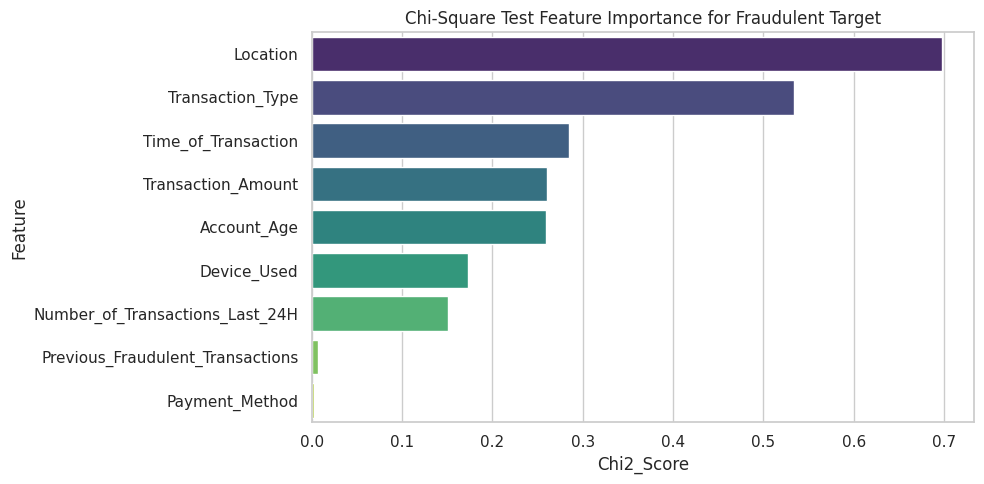

In [ ]:
CATEGORICAL_FEATURES = ["Transaction_Type", "Device_Used", "Location", "Payment_Method"]
NUMERIC_FEATURES = ["Transaction_Amount", "Time_of_Transaction", "Previous_Fraudulent_Transactions",
                    "Account_Age", "Number_of_Transactions_Last_24H"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Convert text categories to integer codes
df_encoded = df_clean.copy()
for column in CATEGORICAL_FEATURES:
    df_encoded[column] = LabelEncoder().fit_transform(df_encoded[column].astype(str))

X_chi = df_encoded[FEATURES].copy()
X_chi = X_chi.fillna(X_chi.median())          # safety net; no gaps remain after cleaning
y_chi = df_encoded["Fraudulent"]

X_chi_scaled = MinMaxScaler().fit_transform(X_chi)

chi_selector = SelectKBest(score_func=chi2, k="all").fit(X_chi_scaled, y_chi)

chi2_df = pd.DataFrame({
    "Feature": FEATURES,
    "Chi2_Score": chi_selector.scores_,
    "P_Value": chi_selector.pvalues_,
}).sort_values(by="Chi2_Score", ascending=False)

print("Chi-Square Test Feature Scores:")
print(chi2_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=chi2_df, x="Chi2_Score", y="Feature", palette="viridis")
plt.title("Chi-Square Test Feature Importance for Fraudulent Target")
plt.tight_layout()
plt.show()

**Interpretation:** the highest score belongs to `Location` (χ² = 0.70, p = 0.40), but **all p-values are far above 0.05**
(range 0.40 – 0.96). So none of the features shows a statistically significant dependence on fraud.
Together with the correlation results, this tells us the features carry very little information about the target –
an important thing to remember when we look at the model results later.

## 5. Train-Test Split & Imbalance Handling
Fraud is rare, so the classes are heavily unbalanced. Steps:

1. Split 70% / 30% with `stratify=y`, so train and test keep the same fraud rate.
2. Apply oversampling to the **training set only** – the test set must stay untouched so it reflects real-world data.



In [ ]:
X = df_encoded[FEATURES].copy()
X = X.fillna(X.median())
y = df_encoded["Fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print("Original Train Set Class Distribution:", Counter(y_train))

oversamplers = {
    "ROS": RandomOverSampler(random_state=SEED),
    "SMOTE": SMOTE(random_state=SEED),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=SEED),
    "ADASYN": ADASYN(random_state=SEED),
}

resampled = {}
for method_name, sampler in oversamplers.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    resampled[method_name] = (X_res, y_res)
    print(f"{method_name} Class Distribution:", Counter(y_res))

# SMOTE-balanced training data is used for the models below
X_smote, y_smote = resampled["SMOTE"]

Original Train Set Class Distribution: Counter({0: 33356, 1: 1727})
ROS Class Distribution: Counter({1: 33356, 0: 33356})
SMOTE Class Distribution: Counter({1: 33356, 0: 33356})
BorderlineSMOTE Class Distribution: Counter({1: 33356, 0: 33356})
ADASYN Class Distribution: Counter({0: 33356, 1: 32960})


**Output:** the training set has **33,356 genuine vs 1,727 fraud** cases (about **95% : 5%**).
ROS, SMOTE and BorderlineSMOTE each raise the fraud class to 33,356 so both classes are equal.
ADASYN ends slightly lower (32,960) because it decides *how many* synthetic rows to create from how hard each region is,
rather than forcing a perfect 50/50 balance.

## 6. Task 5 – Machine Learning Models
Three classifiers are trained on the SMOTE-balanced training data and tested on the original, untouched test set:

* **Logistic Regression** – simple linear baseline
* **Random Forest** – many decision trees voting together
* **Gradient Boosting** – trees built one after another, each correcting the previous errors

Features are standardised (`StandardScaler`) because Logistic Regression is sensitive to feature scale.
The scaler is fitted on the training data only and then applied to the test data.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_smote)
X_test_scaled = scaler.transform(X_test)

classifiers = {
    "Logistic Regression": LogisticRegression(random_state=SEED, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}


def train_and_score(model):
    """Fit a model on the balanced training data and score it on the test set."""
    model.fit(X_train_scaled, y_smote)
    predicted_class = model.predict(X_test_scaled)
    fraud_probability = model.predict_proba(X_test_scaled)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, predicted_class),
        "Precision": precision_score(y_test, predicted_class),
        "Recall": recall_score(y_test, predicted_class),
        "F1-Score": f1_score(y_test, predicted_class),
        "ROC-AUC": roc_auc_score(y_test, fraud_probability),
        "y_pred": predicted_class,
        "y_proba": fraud_probability,
    }


results = {name: train_and_score(model) for name, model in classifiers.items()}

metric_columns = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_summary = pd.DataFrame(results).T[metric_columns]
print("--- Machine Learning Model Results ---")
print(results_summary.to_string())

--- Machine Learning Model Results ---
                     Accuracy Precision    Recall  F1-Score   ROC-AUC
Logistic Regression  0.595105  0.050437  0.405405  0.089713  0.503532
Random Forest        0.870245  0.047797  0.086486  0.061568  0.498547
Gradient Boosting    0.809324  0.042974  0.135135   0.06521  0.493208


**How to read the metrics**

* **Accuracy** – share of all predictions that are correct (misleading when one class dominates)
* **Precision** – of the transactions flagged as fraud, how many really were
* **Recall** – of all real frauds, how many were caught
* **F1-Score** – balance between precision and recall
* **ROC-AUC** – ability to rank fraud above genuine cases (0.5 = random guessing, 1.0 = perfect)

## 7. Result Analysis
The **confusion matrices** show the actual counts of correct and wrong predictions, and the **ROC curves** show
how well each model separates fraud from genuine cases at every threshold. A useful model's curve bows toward the
top-left corner; a curve hugging the dashed diagonal is no better than a coin flip.

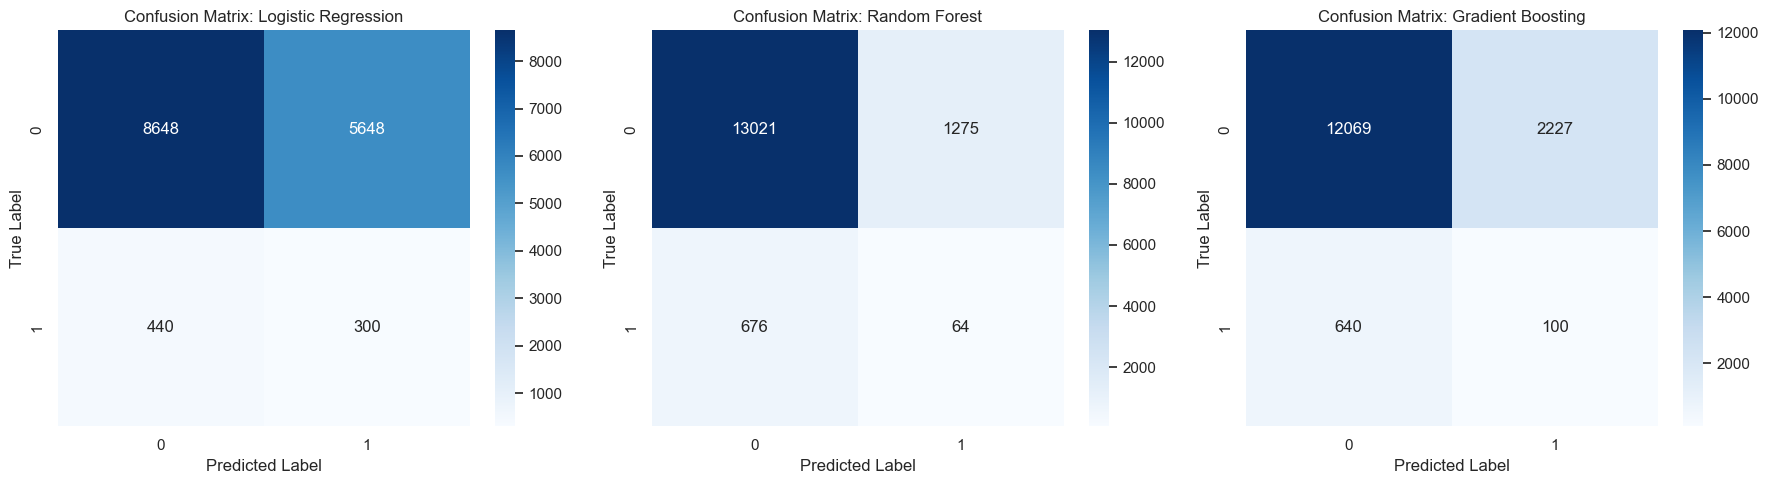

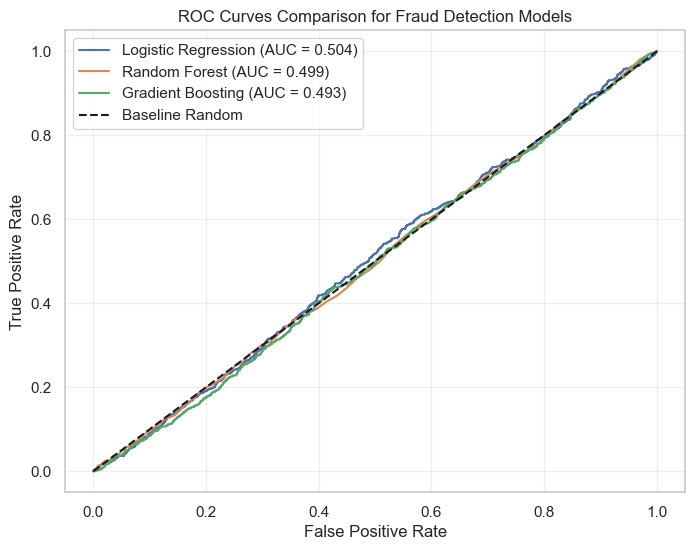

In [ ]:
# Confusion matrices (one panel per model)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

# ROC curves (all models on one plot)
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Baseline Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison for Fraud Detection Models")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Analytical Interpretation & Discussion



### 8.1 Feature analysis
* **Correlation:** all numeric features have |r| < 0.01 with `Fraudulent`.
* **Chi-square:** all p-values lie between 0.40 and 0.96, so no feature is significantly linked to fraud at the 5% level.
* **Conclusion:** the available features are very weak predictors of fraud.

### 8.2 Imbalance handling and model performance
* The data is about **95 : 5** (genuine : fraud). Oversampling balanced the *training* classes (SMOTE → 33,356 each).
* All three models have **ROC-AUC between 0.49 and 0.50**, i.e. essentially **random guessing**. Random Forest (0.499) and
  Logistic Regression (0.504) are statistically indistinguishable from each other, and Gradient Boosting is marginally lower (0.493).
* **Accuracy is misleading here.** Because only about 5% of test transactions are fraud, a "model" that always predicts *genuine* would score about
  **95% accuracy**. Random Forest's 87% and Gradient Boosting's 81% are actually *below* that; they only look reasonable in isolation.
* **Precision is about 4–5% for every model**, which equals the natural fraud rate – the models flag transactions no better than picking them at random.
  Logistic Regression's higher recall (0.41) comes purely from flagging many more transactions as fraud, which also lowers its accuracy to 59.5%.
* **Overall conclusion:** no model should be called "best" on this evidence. The weak correlation and chi-square results already warned that
  the features hold little signal, and the model metrics confirm it.

### 8.3 Possible improvements
* Engineer stronger features (e.g. amount relative to account age, time-of-day bands, transaction velocity ratios).
* Apply SMOTE *inside* cross-validation (e.g. an `imblearn` Pipeline) and use **SMOTENC** or one-hot encoding, because SMOTE on label-encoded categories creates meaningless in-between category codes.
* Judge models with **Precision-Recall AUC** and tune the decision threshold, since accuracy is unreliable for rare-event problems.